In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Install Libraries

In [ ]:
!pip install elevatr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0
  Attempting uninstall: matplotlib
    Found existing 

In [ ]:
!pip install networkx osmnx geopandas numpy pandas matplotlib shapely ipython

  Using cached osmnx-2.1.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached jedi-0.20.0-py2.py3-none-any.whl.metadata (23 kB)
Using cached osmnx-2.1.1-py3-none-any.whl (104 kB)
Using cached jedi-0.20.0-py2.py3-none-any.whl (4.9 MB)


In [ ]:
!pip install openmeteo-requests requests-cache retry-requests pandas --break-system-packages -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.4/230.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.9/809.9 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.4/131.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.0 MB/s eta 0:00:00


# 2. Import libraries

In [ ]:
# for open street map access
import networkx as nx
import osmnx as ox
from IPython.display import IFrame
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plot
from shapely import wkt
import rioxarray # Added to enable .rio accessor

# for open meteo api
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

#
from shapely.geometry import box


# elevatr data
import elevatr  as elv

# see the raster file to get the elevation
import rasterio

# Add elevation to gdf_nodes
import pyproj

# for attaching weather(rain) data in edge
from shapely.geometry import Point
import openmeteo_requests
import requests_cache
from retry_requests import retry

# map visualization for grid cells
import folium

# ox.config(use_cache=True, log_console=True)
%matplotlib inline
ox.__version__

In [3]:
import numpy as np
import pandas as pd

# 3. Open Meteo API (weather - rain) - Section 6 also

In [ ]:
"""
Example: collecting weather features for Model A (flood probability per edge)
- Historical data -> training set (with BfG flood labels joined separately)
- Forecast data   -> inference set (for "3 days from now" resilience question)
"""



# Cache + retry session (avoids hammering the free API, retries on failure)
cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# --- Step 1: your grid points near Trier ---
# In practice: generate these by snapping your OSM edges to a coarse grid
# (e.g., 1km cells) and taking the centroid of each cell.
grid_points = [
    {"id": "cell_1", "lat": 49.7596, "lon": 6.6441},  # Trier city center
    {"id": "cell_2", "lat": 49.7700, "lon": 6.6300},
    # ... add all your grid cells
]


# --- Step 2A: HISTORICAL data (for training) ---
def get_historical(lat, lon, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,   # "2021-07-08"
        "end_date": end_date,       # "2021-07-16"
        "daily": ["precipitation_sum", "soil_moisture_0_to_10cm_mean"],
        "timezone": "Europe/Berlin",
    }
    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    daily = response.Daily()

    df = pd.DataFrame({
        "date": pd.date_range(
            start=pd.to_datetime(daily.Time(), unit="s"),
            end=pd.to_datetime(daily.TimeEnd(), unit="s"),
            freq=pd.Timedelta(seconds=daily.Interval()),
            inclusive="left",
        ),
        "precipitation_sum": daily.Variables(0).ValuesAsNumpy(),
        "soil_moisture": daily.Variables(1).ValuesAsNumpy(),
    })

    # rolling accumulation features — flood risk depends on cumulative rain
    df["rain_3d"] = df["precipitation_sum"].rolling(3, min_periods=1).sum()
    df["rain_7d"] = df["precipitation_sum"].rolling(7, min_periods=1).sum()
    df["lat"], df["lon"] = lat, lon
    return df


# Example: flood period (positive examples) + a dry period (negative examples)
flood_period = ("2021-07-08", "2021-07-16")
dry_period = ("2022-08-01", "2022-08-09")  # pick any known non-flood week

all_rows = []
for point in grid_points:
    flood_df = get_historical(point["lat"], point["lon"], *flood_period)
    flood_df["cell_id"], flood_df["label_period"] = point["id"], "flood"

    dry_df = get_historical(point["lat"], point["lon"], *dry_period)
    dry_df["cell_id"], dry_df["label_period"] = point["id"], "dry"

    all_rows.append(pd.concat([flood_df, dry_df]))

training_weather_df = pd.concat(all_rows, ignore_index=True)
# Next step (outside this script): join training_weather_df with BfG flood
# polygons per cell/edge to get the actual 0/1 "flooded" label.
print(training_weather_df.head())


# --- Step 2B: FORECAST data (for inference — "3 days from now") ---
def get_forecast(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": ["precipitation_sum", "soil_moisture_0_to_10cm_mean"],
        "forecast_days": 7,
        "timezone": "Europe/Berlin",
    }
    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    daily = response.Daily()

    df = pd.DataFrame({
        "date": pd.date_range(
            start=pd.to_datetime(daily.Time(), unit="s"),
            end=pd.to_datetime(daily.TimeEnd(), unit="s"),
            freq=pd.Timedelta(seconds=daily.Interval()),
            inclusive="left",
        ),
        "precipitation_sum": daily.Variables(0).ValuesAsNumpy(),
        "soil_moisture": daily.Variables(1).ValuesAsNumpy(),
    })
    df["rain_3d"] = df["precipitation_sum"].rolling(3, min_periods=1).sum()
    df["rain_7d"] = df["precipitation_sum"].rolling(7, min_periods=1).sum()
    df["lat"], df["lon"] = lat, lon
    return df


forecast_rows = []
for point in grid_points:
    fdf = get_forecast(point["lat"], point["lon"])
    fdf["cell_id"] = point["id"]
    forecast_rows.append(fdf)

forecast_weather_df = pd.concat(forecast_rows, ignore_index=True)
print(forecast_weather_df.head())
# Next step: feed this into your TRAINED Model A -> per-edge flood probability
# for each future date -> plug into RoA computation.

                 date  precipitation_sum  soil_moisture    rain_3d    rain_7d  \
0 2021-07-07 22:00:00               11.1            NaN  11.100000  11.100000   
1 2021-07-08 22:00:00                7.0            NaN  18.100001  18.100001   
2 2021-07-09 22:00:00                4.3            NaN  22.400001  22.400001   
3 2021-07-10 22:00:00                2.3            NaN  13.600001  24.700001   
4 2021-07-11 22:00:00                4.1            NaN  10.700000  28.800001   

       lat     lon cell_id label_period  
0  49.7596  6.6441  cell_1        flood  
1  49.7596  6.6441  cell_1        flood  
2  49.7596  6.6441  cell_1        flood  
3  49.7596  6.6441  cell_1        flood  
4  49.7596  6.6441  cell_1        flood  
                 date  precipitation_sum  soil_moisture  rain_3d  rain_7d  \
0 2026-08-02 22:00:00                0.9            NaN      0.9      0.9   
1 2026-08-03 22:00:00                0.2            NaN      1.1      1.1   
2 2026-08-04 22:00:00         

In [ ]:
training_weather_df.to_csv('training_weather_df.csv', index=False)
forecast_weather_df.to_csv('forecast_weather_df.csv', index=False)

# 4. Access GML files to get the flooded are [Downloaded](https://geoportal.bafg.de/inspire/download/NZ/hazardArea_flood/datasetfeed.xml)

- The data of [Natural Risk zone GML DATA availiable here](https://numis.niedersachsen.de/trefferanzeige;jsessionid=0E892FD18CB2548D1FA17B6EDA7A9161?docuuid=BF19E392-8500-44B7-976E-17A8C11FC445&plugid=%2Fingrid-group%3Aiplug-csw-dsc-nokis&docid=BDuXAn0BSvMD--23p5r5)

- working only medium and high flooded area (low crashing the coolab!)

In [ ]:
# access the gml files
# flood_low = gpd.read_file("/content/drive/MyDrive/RCS v2.0/NZ_hazardArea_fluvial_L-DE_GML.zip")
flood_medium = gpd.read_file("/content/drive/MyDrive/RCS v2.0/NZ_hazardArea_fluvial_M-DE_GML.zip")
# flood_high = gpd.read_file("/content/drive/MyDrive/RCS v2.0/NZ_hazardArea_fluvial_H-DE_GML.zip")

In [ ]:
# column information:
# gml_id – Unique identifier for the polygon.
# beginLifeSpanVersion – Date when this version became valid.
# endLifeSpanVersion – Date when this version ceased to be valid (if applicable).
# localId – Local identifier assigned by the data provider.
# namespace – Organization/namespace that issued the identifier.
# versionId – Version number of the feature.
# qualitativeLikelihood – Flood likelihood category (e.g., low, medium, high).
# probabilityOfOccurrence – Probability or frequency of the flood event.
# returnPeriod – Expected recurrence interval (e.g., 100-year flood).
# assessmentMethod – Method used to generate the flood hazard map.
# magnitudeOrIntensity – Flood intensity or magnitude classification.
# geometry – The polygon geometry representing the flood hazard area.

# print(flood_high.columns)
# print(flood_medium.columns)
# print(flood_low.columns)

Index(['gml_id', 'beginLifeSpanVersion', 'endLifeSpanVersion', 'localId',
       'namespace', 'versionId', 'qualitativeLikelihood',
       'probabilityOfOccurrence', 'returnPeriod', 'assessmentMethod',
       'magnitudeOrIntensity',
       'likelihoodOfOccurrence|LikelihoodOfOccurrence|quantitativeLikelihood|QuantitativeLikelihood|probabilityOfOccurrence',
       'likelihoodOfOccurrence|LikelihoodOfOccurrence|quantitativeLikelihood|QuantitativeLikelihood|returnPeriod',
       'geometry'],
      dtype='object')


In [ ]:
# flood_high.to_csv('flood_high.csv', index=False)
# flood_medium.to_csv('flood_medium.csv', index=False)
# flood_low.to_csv('flood_low.csv', index=False)

In [ ]:
# flood_low.head()

,gml_id,beginLifeSpanVersion,endLifeSpanVersion,localId,namespace,versionId,qualitativeLikelihood,probabilityOfOccurrence,returnPeriod,assessmentMethod,magnitudeOrIntensity,likelihoodOfOccurrence|LikelihoodOfOccurrence|quantitativeLikelihood|QuantitativeLikelihood|probabilityOfOccurrence,likelihoodOfOccurrence|LikelihoodOfOccurrence|quantitativeLikelihood|QuantitativeLikelihood|returnPeriod,geometry
0,nzHA_DERP_RG_264268_MOS_BLS_33_L-85562,None,None,nzHA_DERP_RG_264268_MOS_BLS_33_L-85562,https://registry.gdi-de.org/id/de.bund.bfg.ins...,None,low,None,None,None,None,NaN,NaN,"POLYGON ((7.37434 49.2187, 7.37428 49.21872, 7..."
1,nzHA_DERP_RG_268_MOS_RUS_92_L-85584,None,None,nzHA_DERP_RG_268_MOS_RUS_92_L-85584,https://registry.gdi-de.org/id/de.bund.bfg.ins...,None,low,None,None,None,None,NaN,NaN,"POLYGON ((7.02371 50.01044, 7.02372 50.01045, ..."
2,nzHA_DERP_RG_2724_NRH_SIE_74_L-85643,None,None,nzHA_DERP_RG_2724_NRH_SIE_74_L-85643,https://registry.gdi-de.org/id/de.bund.bfg.ins...,None,low,None,None,None,None,NaN,NaN,"POLYGON ((7.89164 50.62832, 7.89165 50.62833, ..."
3,nzHA_DERP_RG_2548_MRH_ALW_42_L-85644,None,None,nzHA_DERP_RG_2548_MRH_ALW_42_L-85644,https://registry.gdi-de.org/id/de.bund.bfg.ins...,None,low,None,None,None,None,NaN,NaN,"POLYGON ((7.83312 49.78182, 7.83308 49.78183, ..."
4,nzHA_DERP_RG_2654_MOS_MOS_10_L-85657,None,None,nzHA_DERP_RG_2654_MOS_MOS_10_L-85657,https://registry.gdi-de.org/id/de.bund.bfg.ins...,None,low,None,None,None,None,NaN,NaN,"POLYGON ((6.66471 49.77772, 6.66476 49.77774, ..."


In [ ]:
flood_high = pd.read_csv('/content/drive/MyDrive/RCS v2.0/flood_high.csv')
flood_medium = pd.read_csv('/content/drive/MyDrive/RCS v2.0/flood_medium.csv')
flood_low = pd.read_csv('/content/drive/MyDrive/RCS v2.0/flood_low.csv')

In [ ]:
"""
Generate weather grid points covering the full OSM graph area,
then join each edge to its nearest grid point.
"""
# import osmnx as ox
# import geopandas as gpd
# import numpy as np
# from shapely.geometry import Point

# --- Step 1: load your graph (edges/nodes already extracted) ---
# G = ox.graph_from_place("Trier, Germany", network_type="drive")
# For this example, assume G already exists.

def build_weather_grid(G, cell_size_km=1.0):
    nodes, edges = ox.graph_to_gdfs(G)
    minx, miny, maxx, maxy = nodes.total_bounds  # bbox of whole graph

    # rough degree conversion (good enough for city-scale grids)
    deg_step = cell_size_km / 111.0

    xs = np.arange(minx, maxx, deg_step)
    ys = np.arange(miny, maxy, deg_step)

    grid_points = []
    for i, x in enumerate(xs):
        for j, y in enumerate(ys):
            grid_points.append({
                "cell_id": f"cell_{i}_{j}",
                "lat": y,
                "lon": x,
                "geometry": Point(x, y),
            })

    grid_gdf = gpd.GeoDataFrame(grid_points, crs="EPSG:4326")
    return grid_gdf, edges


def join_edges_to_grid(edges, grid_gdf):
    # use edge midpoint for the join
    edges = edges.copy()
    edges["mid_point"] = edges.geometry.centroid
    edges_pts = gpd.GeoDataFrame(edges, geometry="mid_point", crs=edges.crs)

    joined = gpd.sjoin_nearest(edges_pts, grid_gdf, how="left")
    return joined  # each edge now has a cell_id -> weather features


# Usage:
# grid_gdf, edges = build_weather_grid(G, cell_size_km=1.0)
# edges_with_cells = join_edges_to_grid(edges, grid_gdf)
# -> now call Open-Meteo once per row in grid_gdf (not per edge!)
# -> merge weather_df (keyed by cell_id) back onto edges_with_cells

# 5. Use Case Areas : Trier (Drive way only)

In [ ]:
place = "Trier, Germany"
G = ox.graph_from_place(place, network_type="drive")

In [ ]:
G = ox.add_edge_travel_times(ox.add_edge_speeds(G))

In [ ]:
G_proj = ox.project_graph(G)
nodes_proj = ox.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.unary_union.convex_hull.area
ox.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

/tmp/ipykernel_2216/1706246484.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  graph_area_m = nodes_proj.unary_union.convex_hull.area


{'n': 2808,
 'm': 6337,
 'k_avg': 4.513532763532764,
 'edge_length_total': 769326.1738223146,
 'edge_length_avg': 121.40226823770153,
 'streets_per_node_avg': 2.694088319088319,
 'streets_per_node_counts': {0: 0, 1: 535, 2: 76, 3: 1923, 4: 264, 5: 7, 6: 3},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.19052706552706553,
  2: 0.027065527065527065,
  3: 0.6848290598290598,
  4: 0.09401709401709402,
  5: 0.002492877492877493,
  6: 0.0010683760683760685},
 'intersection_count': 2273,
 'street_length_total': 434428.02943177876,
 'street_segment_count': 3789,
 'street_length_avg': 114.65506187167557,
 'circuity_avg': 1.0837827712433854,
 'self_loop_proportion': 0.010820797044074954,
 'clean_intersection_count': 1530,
 'node_density_km': 25.794396545323767,
 'intersection_density_km': 20.879865864501753,
 'edge_density_km': 7067.059971605934,
 'street_density_km': 3990.6726714981787,
 'clean_intersection_density_km': 14.054639143285385}

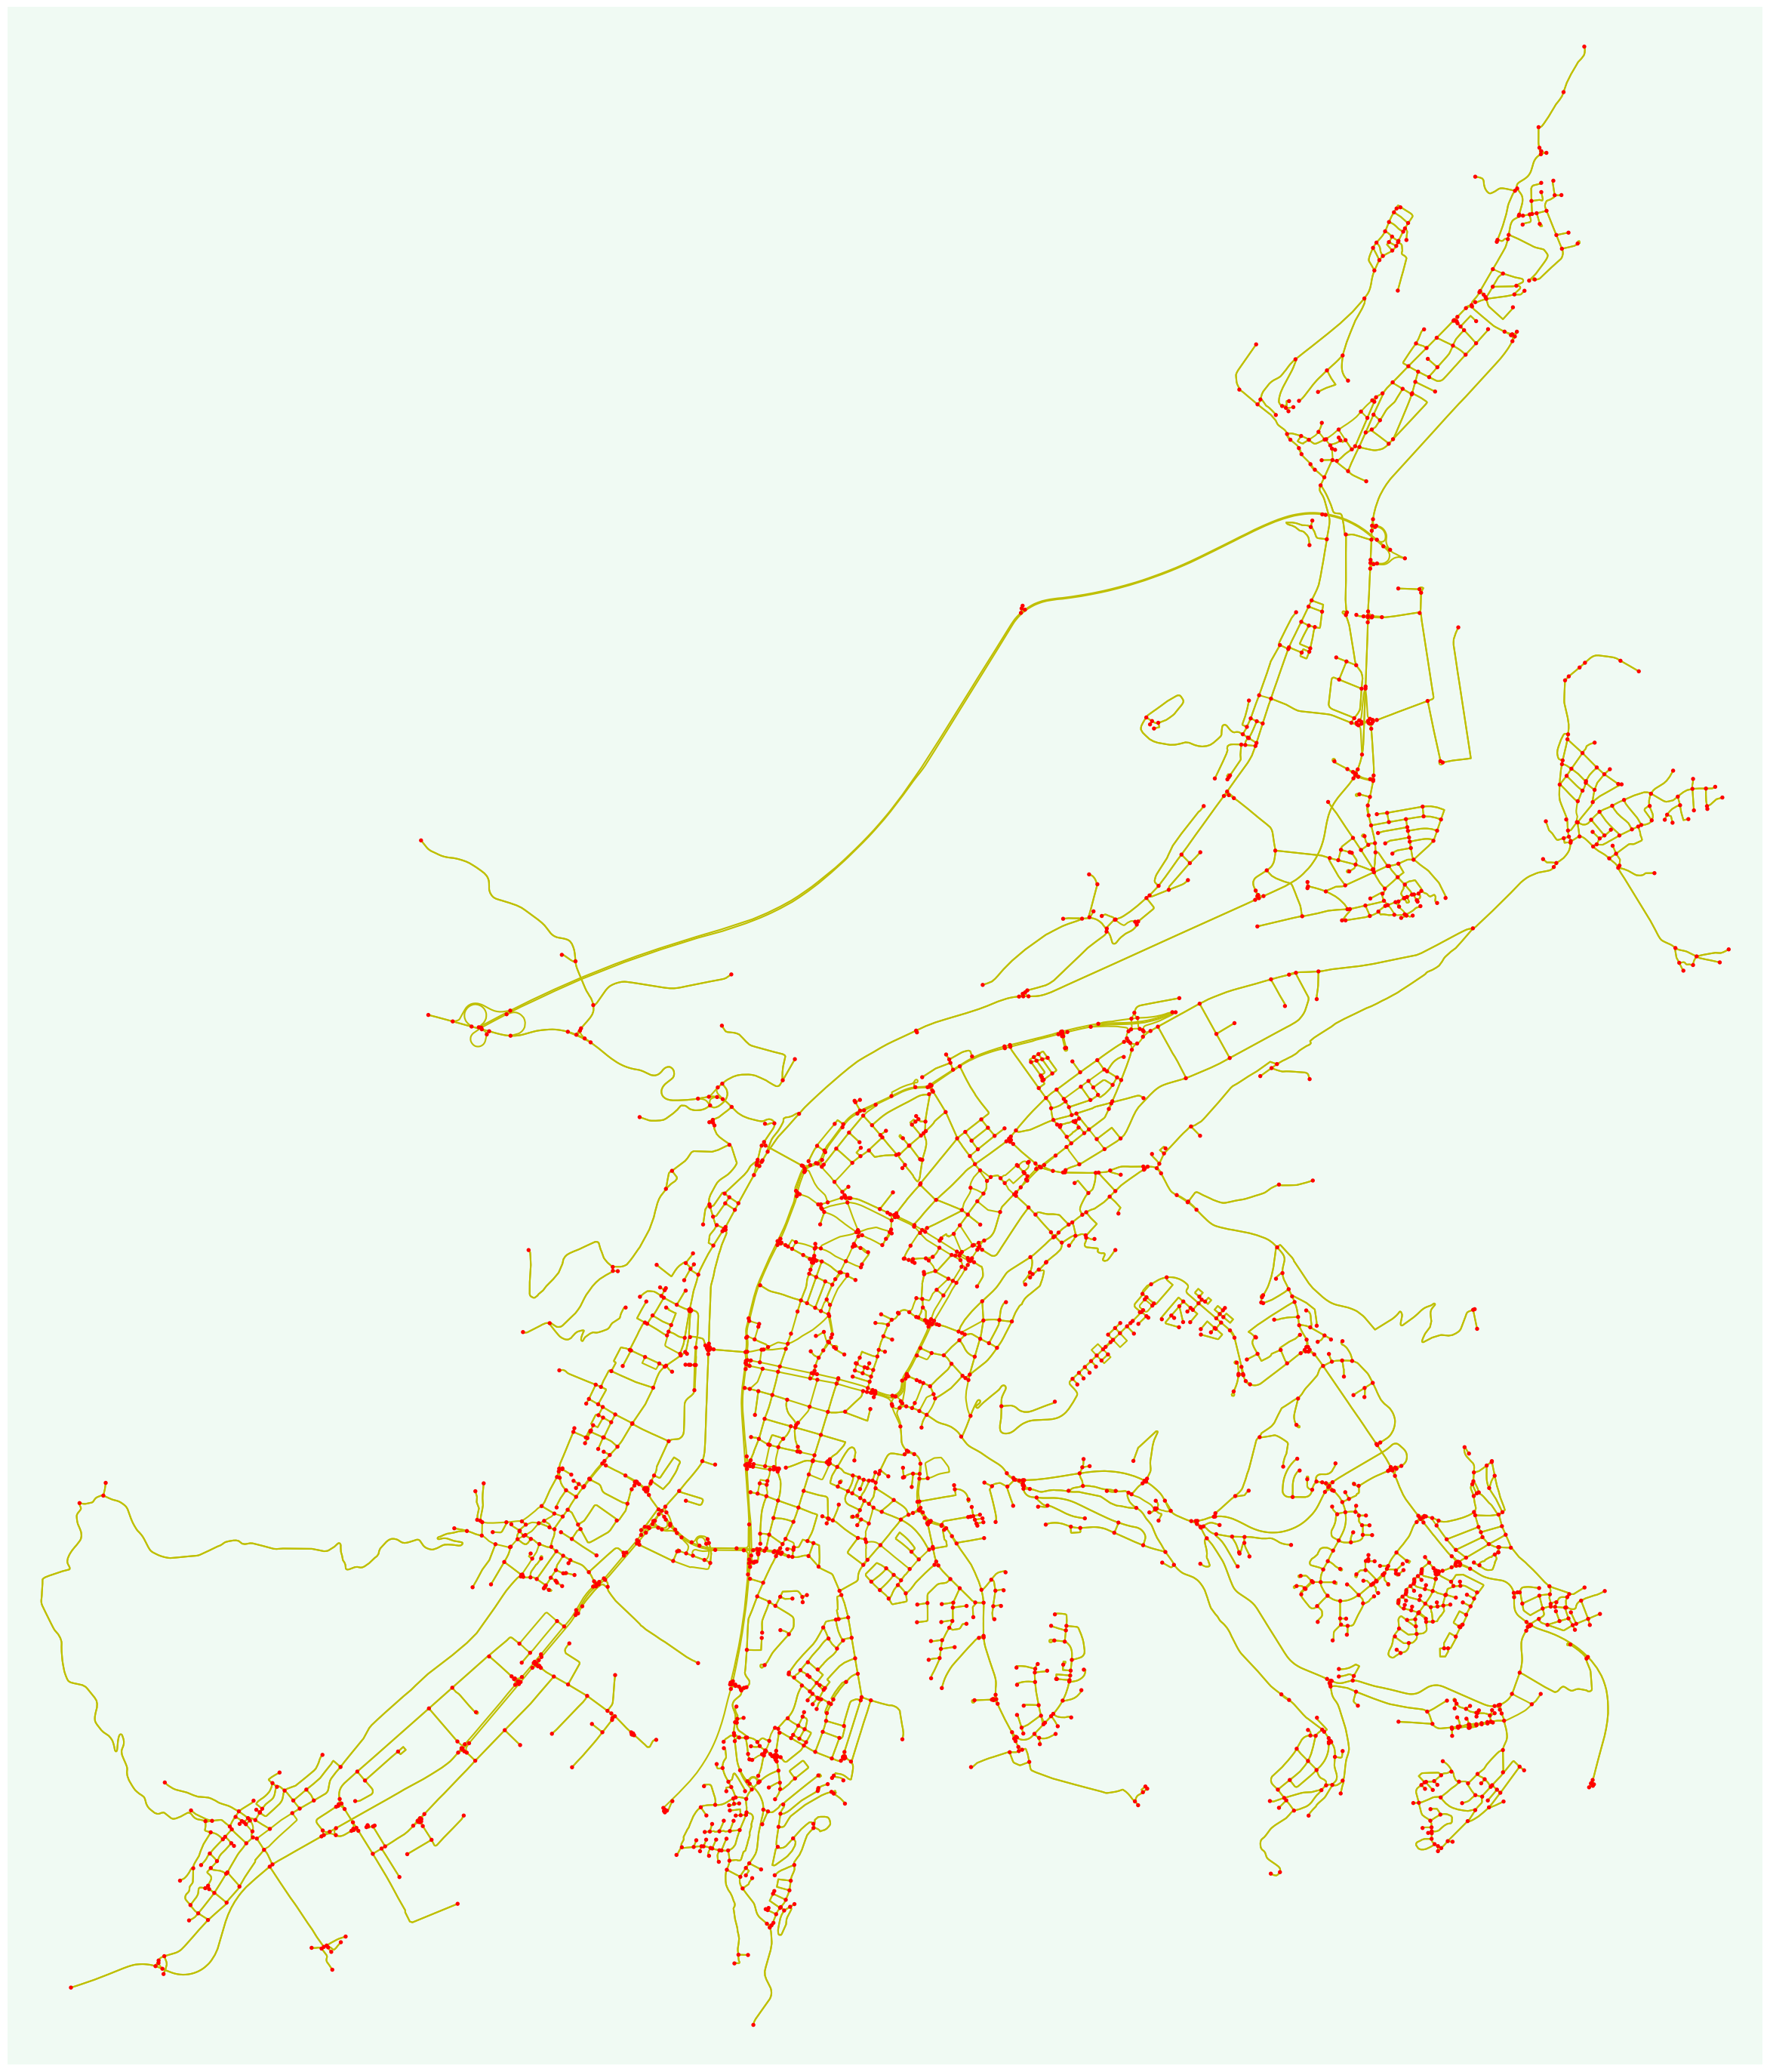

In [ ]:
fig, ax = ox.plot_graph(G, figsize=(30, 50), bgcolor="#f0faf3", node_size=15, edge_color="y",node_color='r', edge_linewidth=1.5)


In [ ]:
# 100 random points from the projected grapg
points = ox.utils_geo.sample_points(ox.convert.to_undirected(G_proj), n = 100)

X = points.x.values
Y = points.y.values

In [ ]:
X

array([335222.55993809, 330031.79963681, 333073.84820478, 330115.40071398,
       334671.21790056, 332599.68436117, 326373.00108226, 334390.36715207,
       333813.82112528, 328337.10779343, 329175.10758988, 330024.18853447,
       326999.02323738, 329531.86360379, 328407.06605608, 325084.4569161 ,
       331915.18936528, 330174.85618765, 334386.98672747, 334042.91120966,
       330542.00911098, 330212.09383865, 330203.38690969, 333112.22379465,
       330977.15676055, 328471.07964501, 329804.78407005, 329478.71375532,
       329521.52516346, 325198.45901285, 331063.04254299, 325524.67772184,
       334147.89688969, 328988.06621663, 328123.88041375, 329585.23604432,
       330241.24092288, 333172.43302534, 327113.4131956 , 334361.28212317,
       329364.52331393, 327539.23294263, 331223.24810935, 327173.14976997,
       329258.69948211, 328880.92014646, 330517.93717272, 334819.21567862,
       330827.13512036, 325634.965305  , 325309.82917945, 329426.4993616 ,
       328942.97917844, 3

In [ ]:
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

## 5.1 saving the edges and nodes in csv file


In [ ]:
gdf_edges.to_csv('trier_edges.csv', index=False)
gdf_nodes.to_csv('trier_nodes.csv', index=False)

In [ ]:
gdf_edges = pd.read_csv('/content/drive/MyDrive/RCS v2.0/trier_edges.csv')
gdf_nodes = pd.read_csv('/content/drive/MyDrive/RCS v2.0/trier_nodes.csv')

In [ ]:
trier_endenger_edges_flood_hazard_risk = pd.read_csv('/content/drive/MyDrive/RCS v2.0/treier_flood_hazard_risk.csv')

In [ ]:
print(gdf_nodes.columns)
print(gdf_edges.columns)
print(trier_endenger_edges_flood_hazard_risk.columns)

Index(['y', 'x', 'street_count', 'highway', 'ref', 'geometry'], dtype='object')
Index(['osmid', 'highway', 'lanes', 'name', 'oneway', 'reversed', 'length',
       'speed_kph', 'travel_time', 'maxspeed', 'ref', 'geometry', 'width',
       'bridge', 'junction', 'access', 'tunnel'],
      dtype='object')
Index(['osmid', 'highway', 'lanes', 'name', 'oneway', 'reversed', 'length',
       'speed_kph', 'travel_time', 'maxspeed', 'ref', 'geometry', 'width',
       'bridge', 'junction', 'access', 'tunnel', 'edge_id',
       'qualitativeLikelihood_high', 'probabilityOfOccurrence_high',
       'returnPeriod_high', 'magnitudeOrIntensity_high', 'flooded_high',
       'qualitativeLikelihood_medium', 'probabilityOfOccurrence_medium',
       'returnPeriod_medium', 'magnitudeOrIntensity_medium', 'flooded_medium'],
      dtype='object')


In [ ]:
trier_endenger_edges_flood_hazard_risk = trier_endenger_edges_flood_hazard_risk.drop('edge_id', axis = 1)

In [ ]:
trier_endenger_edges_flood_hazard_risk.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3079 entries, 0 to 3078
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   osmid                           3079 non-null   object 
 1   highway                         3079 non-null   object 
 2   lanes                           1450 non-null   object 
 3   name                            2750 non-null   object 
 4   oneway                          3079 non-null   bool   
 5   reversed                        3079 non-null   object 
 6   length                          3079 non-null   float64
 7   speed_kph                       3079 non-null   float64
 8   travel_time                     3079 non-null   float64
 9   maxspeed                        2163 non-null   object 
 10  ref                             665 non-null    object 
 11  geometry                        3079 non-null   object 
 12  width                           37

- Marge gdf_edge and trier_endenger_edges_flood_hazard_risk dataframe

In [ ]:
cols_to_add = ['osmid','qualitativeLikelihood_high', 'probabilityOfOccurrence_high',
       'returnPeriod_high', 'magnitudeOrIntensity_high', 'flooded_high',
       'qualitativeLikelihood_medium', 'probabilityOfOccurrence_medium',
       'returnPeriod_medium', 'magnitudeOrIntensity_medium', 'flooded_medium']

# Reset index to make 'u', 'v', 'key' columns from gdf_edges
gdf_edges_for_merge = gdf_edges.reset_index()

# Convert the 'osmid' column in both dataframes to string representation for hashability
# This handles cases where osmid might be a list, making them suitable for merging
gdf_edges_for_merge['osmid_str'] = gdf_edges_for_merge['osmid'].apply(str)
trier_hazard_risk_for_merge = trier_endenger_edges_flood_hazard_risk.copy()
trier_hazard_risk_for_merge['osmid_str'] = trier_hazard_risk_for_merge['osmid'].apply(str)

# Perform the merge using the new 'osmid_str' columns
# Drop original 'osmid' from right df to avoid duplicate column after merge if it exists in cols_to_add
new_gdf_edge = gdf_edges_for_merge.merge(
    trier_hazard_risk_for_merge[cols_to_add + ['osmid_str']].drop(columns=['osmid'], errors='ignore'),
    left_on='osmid_str',
    right_on='osmid_str',
    how='left'
)

# Drop the temporary 'osmid_str' column from the merged DataFrame,
# keeping the original 'osmid' column which might contain lists
new_gdf_edge = new_gdf_edge.drop(columns=['osmid_str'])

In [ ]:
new_gdf_edge.head()

,u,v,key,osmid,highway,lanes,name,oneway,reversed,length,...,qualitativeLikelihood_high,probabilityOfOccurrence_high,returnPeriod_high,magnitudeOrIntensity_high,flooded_high,qualitativeLikelihood_medium,probabilityOfOccurrence_medium,returnPeriod_medium,magnitudeOrIntensity_medium,flooded_medium
0,10602396,3328619455,0,1216112757,residential,1,Neustraße,True,False,5.870375,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,False
1,10602396,3328610208,0,44503497,secondary,2,Kaiserstraße,True,False,153.906349,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,False
2,10602396,20909583,0,113363975,secondary_link,1,NaN,True,False,36.447632,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,False
3,10602410,3212415597,0,6073363,residential,4,NaN,False,False,28.040769,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,False
4,10602410,10602396,0,"[348744826, 44181036]",secondary,3,Kaiserstraße,True,False,219.652277,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,False


In [ ]:
# not _flooded, flooded_medium, flooded_high
new_gdf_edge["not_flooded"] = ~(
    new_gdf_edge["flooded_high"].fillna(False) |
    new_gdf_edge["flooded_medium"].fillna(False)
)

In [ ]:
# still have some null values
new_gdf_edge.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   u                               6337 non-null   int64   
 1   v                               6337 non-null   int64   
 2   key                             6337 non-null   int64   
 3   osmid                           6337 non-null   object  
 4   highway                         6337 non-null   object  
 5   lanes                           2342 non-null   object  
 6   name                            5897 non-null   object  
 7   oneway                          6337 non-null   bool    
 8   reversed                        6337 non-null   object  
 9   length                          6337 non-null   float64 
 10  speed_kph                       6337 non-null   float64 
 11  travel_time                     6337 non-null   float64 
 12  maxspeed    

In [ ]:
# remove null values
new_gdf_edge["flooded_high"] = new_gdf_edge["flooded_high"].fillna(False)
new_gdf_edge["flooded_medium"] = new_gdf_edge["flooded_medium"].fillna(False)

In [ ]:
# convert to int 0/1
new_gdf_edge[["flooded_high", "flooded_medium", "not_flooded"]] = (
    new_gdf_edge[["flooded_high", "flooded_medium", "not_flooded"]]
    .astype(int)
)

In [ ]:
new_gdf_edge[(new_gdf_edge["flooded_high"] == 1)].head(10)

,u,v,key,osmid,highway,lanes,name,oneway,reversed,length,...,probabilityOfOccurrence_high,returnPeriod_high,magnitudeOrIntensity_high,flooded_high,qualitativeLikelihood_medium,probabilityOfOccurrence_medium,returnPeriod_medium,magnitudeOrIntensity_medium,flooded_medium,not_flooded
99,20834066,60387828,0,"[30882836, 9875078]",primary_link,1,NaN,True,False,241.322816,...,0.1,10.0,NaN,1,medium,0.01,100.0,NaN,1,0
100,20834066,2824236812,0,"[356468080, 13883009, 793427598]",primary,"[2, 3]",Pacelliufer,True,False,247.835449,...,0.1,10.0,NaN,1,medium,0.01,100.0,NaN,1,0
104,20834070,9265904903,0,"[1004246096, 8069945, 8069947, 308038758]",unclassified,"[2, 3]",Römerbrücke,False,"[False, True]",226.349775,...,0.1,10.0,NaN,1,medium,0.01,100.0,NaN,1,0
107,20834107,1622442300,0,"[319398250, 484948062, 154683398]",primary,2,Kaiser-Wilhelm-Brücke,True,False,52.237801,...,0.1,10.0,NaN,1,medium,0.01,100.0,NaN,1,0
179,20909449,290831503,0,10565881,residential,NaN,Zur Mühle,False,False,280.245899,...,0.1,10.0,NaN,1,medium,0.01,100.0,NaN,1,0
185,20909458,20909690,0,"[30323088, 30323064, 30323079]",living_street,NaN,Retzgrubenweg,False,True,93.195026,...,0.1,10.0,NaN,1,medium,0.01,100.0,NaN,1,0
299,20909678,20909834,0,25858237,residential,NaN,Olewiger Straße,False,True,24.176136,...,0.1,10.0,NaN,1,medium,0.01,100.0,NaN,1,0
300,20909678,1271427455,0,1356065197,tertiary,2,Olewiger Straße,False,False,93.344068,...,0.1,10.0,NaN,1,medium,0.01,100.0,NaN,1,0
301,20909678,290831012,0,"[1376051955, 1376051956, 7971031]",tertiary,NaN,Kernscheider Höhenweg,False,True,133.687223,...,0.1,10.0,NaN,1,medium,0.01,100.0,NaN,1,0
302,20909690,20909458,0,"[30323064, 30323088, 30323079]",living_street,NaN,Retzgrubenweg,False,False,93.195026,...,0.1,10.0,NaN,1,medium,0.01,100.0,NaN,1,0


In [ ]:
gdf_edges[gdf_edges["flooded_high"] == True].head()

## 4.1 Geting the bounding box for trier from my osm graph

In [ ]:
# get the 4 coordinates of trier
minx, miny, maxx, maxy = gdf_edges.total_bounds
print(minx, miny, maxx, maxy)

6.5587518 49.7090185 6.724927 49.8348343


In [ ]:
# get the polygon from the coordinates for the trier
trier_bbox_polygon = box(minx, miny, maxx, maxy)
print(trier_bbox_polygon)

POLYGON ((6.724927 49.7090185, 6.724927 49.8348343, 6.5587518 49.8348343, 6.5587518 49.7090185, 6.724927 49.7090185))


In [ ]:
# Converts the flood polygons to the same coordinate reference system (CRS) as the road edges.
# Clips the flood dataset so that only flood polygons inside the Trier bounding box are kept.

# Result: flood_high_trier contains only the flood hazard polygons relevant to your Trier road network, making subsequent intersection checks faster.

flood_high_trier = flood_high.to_crs(gdf_edges.crs).clip(trier_bbox_polygon)

In [ ]:
flood_medium_trier = flood_medium.to_crs(gdf_edges.crs).clip(trier_bbox_polygon)

In [ ]:
# flood_low_trier = flood_low.to_crs(gdf_edges.crs).clip(trier_bbox_polygon) # crash the system!!

In [ ]:
flood_high_trier.columns
# flood_medium_trier.columns

Index(['gml_id', 'beginLifeSpanVersion', 'endLifeSpanVersion', 'localId',
       'namespace', 'versionId', 'qualitativeLikelihood',
       'probabilityOfOccurrence', 'returnPeriod', 'assessmentMethod',
       'magnitudeOrIntensity', 'geometry'],
      dtype='object')

In [ ]:
# geometry, qualitativeLikelihood, probabilityOfOccurrence, returnPeriod, magnitudeOrIntensity
# gdf_edges["flood_high"] = gdf_edges.intersects(flood_high_trier.unary_union)

/tmp/ipykernel_1635/2969942694.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_edges["flood_high"] = gdf_edges.intersects(flood_high_trier.unary_union)


In [ ]:
gdf_edges.columns

Index(['osmid', 'highway', 'lanes', 'name', 'oneway', 'reversed', 'length',
       'speed_kph', 'travel_time', 'maxspeed', 'ref', 'geometry', 'width',
       'bridge', 'junction', 'access', 'tunnel', 'edge_id',
       'qualitativeLikelihood_high', 'probabilityOfOccurrence_high',
       'returnPeriod_high', 'magnitudeOrIntensity_high', 'flooded_high',
       'qualitativeLikelihood_medium', 'probabilityOfOccurrence_medium',
       'returnPeriod_medium', 'magnitudeOrIntensity_medium', 'flooded_medium'],
      dtype='object')

In [ ]:
def add_flood_columns(gdf_edges, flood_gdf, suffix):
    '''
    Adding specific columns for flood high/medium/low with
      'edge_id',
       'qualitativeLikelihood_high/medium/low', 'probabilityOfOccurrence_high/medium/low',
       'returnPeriod_high/medium/low', 'magnitudeOrIntensity_high/medium/low', 'flooded_high/medium/low'
    '''
    flood_gdf = flood_gdf[[
        "geometry", "qualitativeLikelihood",
        "probabilityOfOccurrence", "returnPeriod", "magnitudeOrIntensity"
    ]].add_suffix(f"_{suffix}")
    flood_gdf = flood_gdf.rename(columns={f"geometry_{suffix}": "geometry"})
    flood_gdf = flood_gdf.set_geometry("geometry")

    joined = gpd.sjoin(gdf_edges, flood_gdf, how="left", predicate="intersects")
    joined = joined.drop_duplicates(subset="edge_id", keep="first")
    joined[f"flooded_{suffix}"] = joined[f"qualitativeLikelihood_{suffix}"].notna()

    # drop the sjoin's index_right column before next join
    joined = joined.drop(columns=["index_right"], errors="ignore")
    return joined



In [ ]:
gdf_edges['edge_id'] = gdf_edges['osmid'] # run once

In [ ]:
# apply for each severity, chaining results

# gdf_edges = add_flood_columns(gdf_edges, flood_high_trier, "high")
gdf_edges = add_flood_columns(gdf_edges, flood_medium_trier, "medium")
# gdf_edges = add_flood_columns(gdf_edges, flood_low_trier, "low")

### Save after adding new columns in edge dataframe (flood level -high, medium data)

In [ ]:
gdf_edges.to_csv('treier_flood_hazard_risk.csv', index = False)

## 5.2 GeoDataFrame with names

In [ ]:
tags = {"amenity": ["hospital", "fire_station"], "shop": True, "industrial": True}  # customize
gdf_pois = ox.features_from_place(place, tags)

In [ ]:
gdf_pois.shape

(1005, 240)

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

display(gdf_pois.head())

geometry addr:city addr:housenumber  \
element id                                                               
node    246828748  POINT (6.64223 49.75832)     Trier               53   
        246830356  POINT (6.64107 49.75691)     Trier               16   
        272245700  POINT (6.64483 49.76289)     Trier               36   
        277731392   POINT (6.6877 49.74321)       NaN              NaN   
        281804610  POINT (6.64951 49.75328)     Trier               21   

                  addr:postcode       addr:street           branch  \
element id                                                           
node    246828748         54290      Simeonstraße  Galeria Kaufhof   
        246830356         54290        Hauptmarkt              NaN   
        272245700         54292        Maarstraße              NaN   
        277731392           NaN               NaN              NaN   
        281804610         54295  Gartenfeldstraße              NaN   

                   check_date check_date:opening_hours    contact:phone  \
element id                                                                
node    246828748  2024-06-21               2024-06-21  +49 651 9773309   
        246830356  2025-09-07               2025-09-07              NaN   
        272245700  2025-04-28               2025-04-28              NaN   
        277731392  2025-01-01               2025-01-01    +49 651 48499   
        281804610  2025-02-08               2025-02-08              NaN   

                  indoor_seating                    name  \
element id                                                 
node    246828748            yes                  Moback   
        246830356            NaN              Copenhagen   
        272245700            NaN                 Olbertz   
        277731392            NaN  Buchhandlung Stephanus   
        281804610            NaN          Nahkauf Surges   

                                       opening_hours outdoor_seating  \
element id                                                             
node    246828748  Mo-Fr 07:00-18:00; Sa 07:30-18:00              no   
        246830356                  Mo-Sa 10:00-19:00             NaN   
        272245700  Mo-Fr 06:30-13:00; Sa 06:30-12:00             NaN   
        277731392  Mo-Fr 09:00-18:00; Sa 09:00-13:00             NaN   
        281804610  Mo-Fr 08:00-19:00, Sa 08:00-14:00             NaN   

                          shop                        website wheelchair  \
element id                                                                 
node    246828748       bakery         https://www.moback.de/        yes   
        246830356        shoes                            NaN        yes   
        272245700       bakery                            NaN        NaN   
        277731392        books      https://www.stephanus.de/        yes   
        281804610  supermarket  https://www.nahkauf-surges.de    limited   

                  addr:country  start_date access:covid19 payment:cash  \
element id                                                               
node    246828748          NaN         NaN            NaN          NaN   
        246830356           DE  2023-05-13            NaN          NaN   
        272245700          NaN        1899            yes          yes   
        277731392          NaN         NaN            NaN          NaN   
        281804610           DE         NaN            NaN          yes   

                  payment:debit_cards    brand brand:wikidata internet_access  \
element id                                                                      
node    246828748                 NaN      NaN            NaN             NaN   
        246830356                 NaN      NaN            NaN             NaN   
        272245700                  no      NaN            NaN             NaN   
        277731392                 NaN      NaN            NaN             NaN   
        281804610                 N

In [ ]:
gdf_pois.columns

Index(['geometry', 'addr:city', 'addr:housenumber', 'addr:postcode',
       'addr:street', 'branch', 'check_date', 'check_date:opening_hours',
       'contact:phone', 'indoor_seating',
       ...
       'service:vehicle:car_repair', 'service:vehicle:inspection',
       'service:vehicle:oil_change', 'service:vehicle:tyres', 'nohousenumber',
       'area', 'building:part', 'healthcare:speciality', 'type',
       'designation'],
      dtype='object', length=240)

In [ ]:
print(gdf_pois.columns.tolist())

['geometry', 'addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street', 'branch', 'check_date', 'check_date:opening_hours', 'contact:phone', 'indoor_seating', 'name', 'opening_hours', 'outdoor_seating', 'shop', 'website', 'wheelchair', 'addr:country', 'start_date', 'access:covid19', 'payment:cash', 'payment:debit_cards', 'brand', 'brand:wikidata', 'internet_access', 'payment:american_express', 'payment:cryptocurrencies', 'payment:electronic_purses', 'payment:girocard', 'payment:mastercard', 'payment:visa', 'phone', 'female', 'male', 'drink:coffee', 'drink:coffee:togo', 'drink:cola', 'drink:viez', 'opening_hours:signed', 'takeaway:covid19', 'brand:wikipedia', 'level', 'addr:suburb', 'contact:fax', 'contact:email', 'contact:website', 'toilets:wheelchair', 'service:bicycle:pump', 'service:bicycle:repair', 'service:bicycle:retail', 'service:bicycle:second_hand', 'motorcycle:clothes', 'motorcycle:parts', 'operator', 'payment:maestro', 'payment:v_pay', 'smoking', 'source', 'takeaway', 

## 5.3 lookup table for frontend drop down box input [Supply Chain Disruption Using RoA](https://github.com/monochandan/Supply-chain-disruption-measurement-using-RoA)

In [ ]:
gdf_pois[['name', 'shop', 'amenity', 'industrial']].sample(100)

name  \
element  id                                                               
node     5830203973                                     Hair by Camilla   
         5300668278                                             Canvero   
         6341902190                                                 NaN   
         13950247342                    Kurz oder lang - Friseur Linden   
         2415992860                                                Kult   
         1429718571                                            Aldi Süd   
way      111687544                                        Reifen Kiefer   
node     3295585413                                      Bijou Brigitte   
         3326073891                                       Rotweinkeller   
         272245700                                              Olbertz   
         2529197454                                            Aldi Süd   
         4329409139                                  Fleischerei Martin   
         3295585412                                       The Body Shop   
         4331125580                                  Alfred Lentes GmbH   
         5578973218                                              Medusa   
         4202416098                                           Wolsdorff   
         4637403010                                              Gebers   
         11307437940                                              Dietz   
way      320435016                                        Heizöl Müller   
node     4656624671                                    REWE Tim Schirra   
         4653542198                                       Rolladen Pütz   
         9431073678                                        Die Lohner's   
         4335369276                                                ltur   
         12182752354                     Cosmetic Institut Zara Basereh   
         5357662784                                         La Rochelle   
         4329414399                                  Belle's Körperkult   
         676537737                                             GriscArt   
         4294405112                                   Bäckerei Heckmann   
         474386236                            Polo Motorrad Store Trier   
         6576126575                                     Picasso Friseur   
         5514934417                                Autoverwertung Trier   
         4712249197                                            Konplott   
way      32718985                                                  Lidl   
node     1978500804                                              Merlot   
         11301980435                                   junited Autoglas   
         4712249207                                              Christ   
         5126396389                          Friseursalon Kurt Fellmann   
         3269465419                                               Voilá   
         3233907002                                               Edeka   
         2529203306                                           Woolworth   
way      149913385                   Freiwillige Feuerwehr Trier-Biewer   
node     8402433182                                Therapiezentrum Höff   
         4223916053                                               Takko   
         7733520882                                            Husshaar   
         1429718568                                            Kaufland   
way      147182357                                 Kaminstudio Wittrock   
node     1429718578                                       Takko Fashion   
         6015845328                                           Key Store   
         12176728202                                            hautnah   
         11482986408                                          Green Box   
way      335727711                                      Schlafwerkstatt   
node     11948010713                                   Haarstudio Bernd   
         19785008

In [ ]:
gdf_pois_filtered = gdf_pois[gdf_pois['industrial'].notna()]
display(gdf_pois_filtered[['name','industrial']].head())

name  \
element id                                                              
way     113244501   A.R.T. Abfallberatungs- und Verwertungsgesells...   
        119803313                                                 NaN   
        120913341                                                 NaN   
        151847918                                                 NaN   
        1338262213                                                NaN   

                    industrial  
element id                      
way     113244501      factory  
        119803313   scrap_yard  
        120913341         port  
        151847918      factory  
        1338262213        yard

In [ ]:
cols = ['name', 'shop', 'amenity', 'industrial', 'geometry']
gdf_pois = gdf_pois[cols]

In [ ]:
gdf_pois.sample()

,,name,shop,amenity,industrial,geometry
element,id,,,,,
node,5300668273,La petite Tulipe,pastry,NaN,NaN,POINT (6.64188 49.75471)


In [ ]:
for index, row in gdf_pois.iterrows():
  if pd.isna(row["name"]):
    if pd.notna(row["amenity"]):
      gdf_pois.at[index, "name"] = row["amenity"]
    elif pd.notna(row["shop"]):
      gdf_pois.at[index, "name"] = row["shop"]
    elif pd.notna(row["industrial"]):
      gdf_pois.at[index, "name"] = row["industrial"]
    else:
      gdf_pois.at[index, "name"] = "no_name"

In [ ]:
display(gdf_pois[['name','industrial']])

name  \
element  id                                                               
node     246828748                                               Moback   
         246830356                                           Copenhagen   
         272245700                                              Olbertz   
         277731392                               Buchhandlung Stephanus   
         281804610                                       Nahkauf Surges   
         290451329                                            Haarmonie   
         290672130                                            Weltladen   
         290672165                                Palastgarten-Terrasse   
         295996109                                             Back-Eck   
         331278608                     Textilreinigung Helmut Rottstock   
         331290380                                Brotstube Albertmühle   
         333734714                                             Fielmann   
         342810351                                             Aldi Süd   
         342810354                                                Edeka   
         344911462                                Weyand Geschenkdesign   
         358429229                                      Kleine Fluchten   
         371070902                                       Henn Zweiräder   
         390892274                                      Mila's Backwelt   
         459967469                                Edu's Wurstmanufaktur   
         459984656                                         Die Lohner's   
         474385805                                 Louis Motorrad Trier   
         474386236                            Polo Motorrad Store Trier   
         510035714                                    Nahkauf philly b.   
         510035718                           Conditorei Confiserie Raab   
         510053833           T.N.T. / Naderi - Herren-und Kinderfriseur   
         577320460                                 Fleischerei Schaefer   
         577321121                               Moback - Bäckerei Jost   
         577326193                                      Haarphilosophie   
         599622014                                         Salon Flügel   
         615414158                              Fahrradstation Gleis 11   
         615666811                                         Edeka Center   
         621202386                                               Tipico   
         621213459                                     Minhs Asia Markt   
         632507895                                  Galerie Kaschenbach   
         632507896                      Schuhe Berg... Schuhe zum Leben   
         632507902                                             Bügelfix   
         632507903                                         Perlenträume   
         632507917                                         Cotton Press   
         632507920                                         Werkstatt 63   
         632524417                                    Blumen Grünhäuser   
         635009361                                         Jack & Jones   
         635022496                                          Hochstetter   
         635742946                                          Hunkemöller   
         635743135                                        Olymp & Hades   
         635743721                                      Intersport Plum   
         638999907                                          Radio Meyer   
         641253087                                        Bäckerei Benz   
         641253094                                    Le Petit Coiffeur   
         641253124                                                Blang   
         641253141                                                Dietz   
         641253145                                                NORMA   
         641253172                                 Biebelhausener Mühle   
         64462198

In [ ]:
gdf_pois['lat'] = gdf_pois.geometry.centroid.y
gdf_pois['lon'] = gdf_pois.geometry.centroid.x
gdf_pois['nearest_node'] = ox.distance.nearest_nodes(G, X=gdf_pois['lon'], Y=gdf_pois['lat'])

gdf_pois[['name', 'shop', 'amenity', 'industrial', 'lat', 'lon', 'nearest_node']].to_csv('trier_locations.csv', index=False)

/tmp/ipykernel_1352/524394441.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_pois['lat'] = gdf_pois.geometry.centroid.y
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_1352/524394441.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_pois['lon'] = gdf_pois.geometry.centroid.x
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:

In [ ]:
gdf_pois.head()

name         shop amenity industrial  \
element id                                                                  
node    246828748                  Moback       bakery     NaN        NaN   
        246830356              Copenhagen        shoes     NaN        NaN   
        272245700                 Olbertz       bakery     NaN        NaN   
        277731392  Buchhandlung Stephanus        books     NaN        NaN   
        281804610          Nahkauf Surges  supermarket     NaN        NaN   

                                   geometry        lat       lon  nearest_node  
element id                                                                      
node    246828748  POINT (6.64223 49.75832)  49.758322  6.642228    3824573783  
        246830356  POINT (6.64107 49.75691)  49.756912  6.641070     132497983  
        272245700  POINT (6.64483 49.76289)  49.762888  6.644834    9519110452  
        277731392   POINT (6.6877 49.74321)  49.743209  6.687703    5243671477  
        281804610  POINT (6.64951 49.75328)  49.753281  6.649508     281807727

## 5.4 Save the data for this [project](https://github.com/monochandan/Supply-chain-disruption-measurement-using-RoA)

In [ ]:
gdf_pois[['name', 'shop', 'amenity', 'industrial', 'lat', 'lon', 'nearest_node']].to_csv('trier_locations.csv', index=False)

## 5.5 After (gdf_nodes , gdf_edges.columns, trier_endenger_edges_flood_hazard_risk.columns) this dataframed loading

### Add elivation to the nodes

In [ ]:
box = (6.5587518, 49.7090185, 6.724927, 49.8348343)

In [ ]:
zoom = 10
raster = elv.get_elev_raster(locations = box, zoom = zoom)s
# raster.rio.to_raster("trier_elevation.tif")

<class 'elevatr.raster.Raster'>


In [ ]:
raster.to_tif("trier_elevation.tif")

### see the elevation of a point

In [ ]:
# import pyproj

with rasterio.open("/content/drive/MyDrive/RCS v2.0/trier_elevation.tif") as f:
  dem_data = f.read(1) # Band 1 typically contains elevation
  print(f"Dem Data: {dem_data}")

  # Get metadata such as coordinates and resolution
  print(f"Bounds: {f.bounds}")
  print(f"Resolution: {f.res}")

  # The input x, y are in WGS84 (lon, lat)
  lon_wgs84, lat_wgs84 = 6.64, 49.76

  # Define the WGS84 CRS (source CRS)
  crs_wgs84 = pyproj.CRS("EPSG:4326")
  # Define the raster's CRS (destination CRS)
  crs_raster = f.crs

  # Create a transformer to convert WGS84 to the raster's CRS
  transformer = pyproj.Transformer.from_crs(crs_wgs84, crs_raster, always_xy=True)

  # Transform the coordinates
  x_raster, y_raster = transformer.transform(lon_wgs84, lat_wgs84)

  # Get row and col indices using the transformed coordinates
  row, col = f.index(x_raster, y_raster)

  # Check if indices are within bounds before accessing
  if 0 <= row < dem_data.shape[0] and 0 <= col < dem_data.shape[1]:
      # Get elevation value at that point (corrected indexing)
      elevation = dem_data[row, col]
      print(f"Elevation at ({lon_wgs84}, {lat_wgs84}): {elevation} meters")
  else:
      print(f"Coordinates ({lon_wgs84}, {lat_wgs84}) are outside the raster bounds after transformation.")

Dem Data: [[372 365 357 ... 277 260 242]
 [374 368 360 ... 272 255 236]
 [376 370 363 ... 268 251 233]
 ...
 [164 165 166 ... 354 365 374]
 [164 165 165 ... 348 358 366]
 [164 165 165 ... 338 348 354]]
Bounds: BoundingBox(left=730116.9106154664, bottom=6396012.917031489, right=748614.671460479, top=6417721.033064479)
Resolution: (76.43702828517621, 76.43702828517416)
Elevation at (6.64, 49.76): 134 meters


/tmp/ipykernel_4056/1078557154.py:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dem_data = f.read(1) # Band 1 typically contains elevation


### Add elevation to the node dataframe

In [ ]:
# Open the raster file once
with rasterio.open("/content/drive/MyDrive/RCS v2.0/trier_elevation.tif") as f:
    dem_data = f.read(1)
    crs_raster = f.crs
    transform_raster = f.transform

    # Define the WGS84 CRS
    crs_wgs84 = pyproj.CRS("EPSG:4326")
    transformer = pyproj.Transformer.from_crs(crs_wgs84, crs_raster, always_xy=True)

    elevations = []
    # Iterate through gdf_nodes to get elevation for each node
    for idx, node in gdf_nodes.iterrows():
        lon_wgs84 = node['x'] # Longitude
        lat_wgs84 = node['y'] # Latitude

        # Transform coordinates
        x_raster, y_raster = transformer.transform(lon_wgs84, lat_wgs84)

        # Get row and col indices
        row, col = f.index(x_raster, y_raster)

        # Get elevation if indices are within bounds, otherwise assign NaN
        if 0 <= row < dem_data.shape[0] and 0 <= col < dem_data.shape[1]:
            elevations.append(dem_data[row, col])
        else:
            elevations.append(np.nan) # Assign NaN for points outside raster bounds

    # Add elevations to gdf_nodes
gdf_nodes['elevation'] = elevations

print(gdf_nodes.head())

/tmp/ipykernel_2457/495606842.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dem_data = f.read(1)


                  y         x  street_count highway  ref  \
osmid                                                      
10602396  49.750094  6.637228             4     NaN  NaN   
10602410  49.749518  6.640148             4     NaN  NaN   
10602412  49.753861  6.642500             3     NaN  NaN   
10602431  49.754348  6.644230             3     NaN  NaN   
10602432  49.753841  6.645782             3     NaN  NaN   

                          geometry  elevation  dist_to_river  
osmid                                                         
10602396  POINT (6.63723 49.75009)      141.0       0.011110  
10602410  POINT (6.64015 49.74952)      145.0       0.014085  
10602412   POINT (6.6425 49.75386)      144.0       0.014912  
10602431  POINT (6.64423 49.75435)      144.0       0.015533  
10602432  POINT (6.64578 49.75384)      142.0       0.016763  


In [ ]:
gdf_nodes.head()

,y,x,street_count,highway,ref,geometry,elevation,dist_to_river
osmid,,,,,,,,
10602396,49.750094,6.637228,4,NaN,NaN,POINT (6.63723 49.75009),141.0,0.011110
10602410,49.749518,6.640148,4,NaN,NaN,POINT (6.64015 49.74952),145.0,0.014085
10602412,49.753861,6.642500,3,NaN,NaN,POINT (6.6425 49.75386),144.0,0.014912
10602431,49.754348,6.644230,3,NaN,NaN,POINT (6.64423 49.75435),144.0,0.015533
10602432,49.753841,6.645782,3,NaN,NaN,POINT (6.64578 49.75384),142.0,0.016763


In [ ]:
new_gdf_edge.head()

,u,v,key,osmid,highway,lanes,name,oneway,reversed,length,...,probabilityOfOccurrence_high,returnPeriod_high,magnitudeOrIntensity_high,flooded_high,qualitativeLikelihood_medium,probabilityOfOccurrence_medium,returnPeriod_medium,magnitudeOrIntensity_medium,flooded_medium,not_flooded
0,10602396,3328619455,0,1216112757,residential,1,Neustraße,True,False,5.870375,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,1
1,10602396,3328610208,0,44503497,secondary,2,Kaiserstraße,True,False,153.906349,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,1
2,10602396,20909583,0,113363975,secondary_link,1,NaN,True,False,36.447632,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,1
3,10602410,3212415597,0,6073363,residential,4,NaN,False,False,28.040769,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,1
4,10602410,10602396,0,"[348744826, 44181036]",secondary,3,Kaiserstraße,True,False,219.652277,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,1


### Distance to river

In [ ]:
rivers = ox.features_from_place("Trier, Germany", tags={"waterway": "river"})
rivers = rivers.to_crs(gdf_nodes.crs)
gdf_nodes["dist_to_river"] = gdf_nodes.geometry.apply(lambda pt: rivers.distance(pt).min())

/tmp/ipykernel_2457/1560965421.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_nodes["dist_to_river"] = gdf_nodes.geometry.apply(lambda pt: rivers.distance(pt).min())


### aggregating nodes features into edge
- avg elevation of edge
- avg river distance

In [ ]:
new_gdf_edge.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   u                               6337 non-null   int64   
 1   v                               6337 non-null   int64   
 2   key                             6337 non-null   int64   
 3   osmid                           6337 non-null   object  
 4   highway                         6337 non-null   object  
 5   lanes                           2342 non-null   object  
 6   name                            5897 non-null   object  
 7   oneway                          6337 non-null   bool    
 8   reversed                        6337 non-null   object  
 9   length                          6337 non-null   float64 
 10  speed_kph                       6337 non-null   float64 
 11  travel_time                     6337 non-null   float64 
 12  maxspeed    

In [ ]:
gdf_edges["elevation_avg"] = gdf_edges.apply(lambda r: (gdf_nodes.loc[r.name[0],"elevation"] + gdf_nodes.loc[r.name[1],"elevation"]) / 2, axis=1)
gdf_edges["dist_to_river_avg"] = gdf_edges.apply(lambda r: (gdf_nodes.loc[r.name[0],"dist_to_river"] + gdf_nodes.loc[r.name[1],"dist_to_river"]) / 2, axis=1)

In [ ]:
new_gdf_edge["elevation_avg"] = new_gdf_edge.apply(lambda r: (gdf_nodes.loc[r.u,"elevation"] + gdf_nodes.loc[r.v,"elevation"]) / 2, axis=1)
new_gdf_edge["dist_to_river_avg"] = new_gdf_edge.apply(lambda r: (gdf_nodes.loc[r.u,"dist_to_river"] + gdf_nodes.loc[r.v,"dist_to_river"]) / 2, axis=1)

# OpenMeteo API to build

- From edge data frame

In [ ]:
cache_session = requests_cache.CachedSession(".cache", expire_after = 3600)
retry_session = retry(retries=5, backoff_factor=0.2, session = cache_session)
openmeteo = openmeteo_requests.Client(session = retry_session)

## build multiple grid per km from edges,  and then store in gpddataframe

In [ ]:
def build_grid(gef_edges, cell_size_km = 1.0):
  minx, miny, maxx, maxy = gef_edges.total_bounds
  print(f"Total bound of triers esges: ({minx, miny, maxx, maxy})")
  deg_step = cell_size_km / 111.0 # km -> degree conversion

  xs = np.arange(minx, maxx, deg_step) # array of all x
  ys = np.arange(miny, maxy, deg_step) # array of all y

  rows = []

  for i, x in enumerate(xs):
    for j, y in enumerate(ys):
      rows.append({"cell_id": f"cell_{i}_{j}", "lat": y, "lon": x, "geometry": Point(x, y)})

  return gpd.GeoDataFrame(rows, crs = "EPSG:4326")

## Call openmeteo onece per grid **point**

In [ ]:
def get_weather_for_point(lat, lon, start_date, end_date):
  url = "https://archive-api.open-meteo.com/v1/archive"
  params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,   # "2021-07-08"
        "end_date": end_date,       # "2021-07-16"
        "daily": ["precipitation_sum", "soil_moisture_0_to_10cm_mean"],
        "timezone": "Europe/Berlin",
    }
  responses = openmeteo.weather_api(url, params=params)
  response = responses[0]
  daily = response.Daily()

  df = pd.DataFrame({
        # "date": pd.date_range(
        #     start=pd.to_datetime(daily.Time(), unit="s"),
        #     end=pd.to_datetime(daily.TimeEnd(), unit="s"),
        #     freq=pd.Timedelta(seconds=daily.Interval()),
        #     inclusive="left",
        # ),
        "precipitation_sum": daily.Variables(0).ValuesAsNumpy(),
        "soil_moisture": daily.Variables(1).ValuesAsNumpy(),
    })

    # rolling accumulation features — flood risk depends on cumulative rain
    # df["rain_3d"] = df["precipitation_sum"].rolling(3, min_periods=1).sum()
    # df["rain_7d"] = df["precipitation_sum"].rolling(7, min_periods=1).sum()
    # df["lat"], df["lon"] = lat, lon
  return pd.Series({
        "rain_3d": df["precipitation_sum"].tail(3).sum(), # .rolling(3, min_periods=1).sum().iloc[-1],
        "rain_7d": df["precipitation_sum"].tail(3).sum(), # .rolling(7, min_periods=1).sum().iloc[-1],
        "soil_moistutre": df["soil_moisture"].mean()

    })



## build weather table

In [ ]:
def build_table(grid_gdf, start_date, end_date):
  records = []

  for _, row in grid_gdf.iterrows():
    weather = get_weather_for_point(row["lat"], row["lon"], start_date, end_date)
    weather["cell_id"] = row["cell_id"]

    records.append(weather)

  return pd.DataFrame(records)

## Attach weather to edge via nearest grid points

In [ ]:
def attach_weather_to_edges(edges, grid_gdf, weather_df):
    edges = edges.copy()
    edges["mid_point"] = edges.geometry.centroid
    edges_pts = gpd.GeoDataFrame(edges, geometry="mid_point", crs=edges.crs)

    nearest = gpd.sjoin_nearest(edges_pts, grid_gdf[["cell_id", "geometry"]], how="left")
    nearest = nearest.merge(weather_df, on="cell_id", how="left")
    nearest = nearest.drop(columns=["mid_point", "index_right"], errors="ignore")
    return nearest

## call the functions

In [ ]:
# call build_grid()
grid_gdf = build_grid(new_gdf_edge, cell_size_km=1.0)

Total bound of triers esges: ((np.float64(6.5587518), np.float64(49.7090185), np.float64(6.724927), np.float64(49.8348343)))


In [ ]:
# check grid_gdf
grid_gdf.shape

(266, 4)

- folium map

In [ ]:
print(grid_gdf["lat"].mean())
print(grid_gdf["lon"].mean())

49.76757705855854
6.639832881081083


In [ ]:
m = folium.Map(location=[grid_gdf["lat"].mean(), grid_gdf["lon"].mean()], zoom_start=10)

# colors = ["green", "blue"]

for index, row in grid_gdf.iterrows():
  folium.Marker(
      location = [row["lat"], row["lon"]],
      popup = row["cell_id"], # as popup display
      icon = folium.Icon(color = "blue")
  ).add_to(m)

  m.save("grids_trier.html")
  m

In [ ]:
# call build_weather_table
weather_df = build_table(grid_gdf, start_date = "2021-07-08", end_date = "2021-07-16")

# check the df
weather_df.head()

,rain_3d,rain_7d,soil_moistutre,cell_id
0,94.100006,94.100006,NaN,cell_0_0
1,94.100006,94.100006,NaN,cell_0_1
2,94.100006,94.100006,NaN,cell_0_2
3,94.100006,94.100006,NaN,cell_0_3
4,94.100006,94.100006,NaN,cell_0_4


In [ ]:
# attach_weather_to_edges
final_edges = attach_weather_to_edges(new_gdf_edge, grid_gdf, weather_df)


/tmp/ipykernel_2457/2653935455.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  edges["mid_point"] = edges.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [ ]:
final_edges.columns

Index(['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'name', 'oneway',
       'reversed', 'length', 'speed_kph', 'travel_time', 'maxspeed', 'ref',
       'geometry', 'width', 'bridge', 'junction', 'access', 'tunnel',
       'elevation_avg', 'dist_to_river_avg', 'qualitativeLikelihood_high',
       'probabilityOfOccurrence_high', 'returnPeriod_high',
       'magnitudeOrIntensity_high', 'flooded_high',
       'qualitativeLikelihood_medium', 'probabilityOfOccurrence_medium',
       'returnPeriod_medium', 'magnitudeOrIntensity_medium', 'flooded_medium',
       'not_flooded', 'cell_id', 'rain_3d', 'rain_7d', 'soil_moistutre'],
      dtype='object')

In [ ]:
gdf_nodes.columns

Index(['y', 'x', 'street_count', 'highway', 'ref', 'geometry', 'elevation',
       'dist_to_river'],
      dtype='object')

In [ ]:
gdf_nodes.columns

Index(['y', 'x', 'street_count', 'highway', 'ref', 'geometry', 'elevation',
       'dist_to_river'],
      dtype='object')

In [ ]:
final_edges.to_csv("final_edges_data_for_training.csv", index = False)
gdf_nodes.to_csv("final_nodes.csv", index = False)

# 6. Model Training

## 6.1 Load the data

In [ ]:
nodes = pd.read_csv("/content/drive/MyDrive/RCS v2.0/final_nodes.csv")
edges = pd.read_csv("/content/drive/MyDrive/RCS v2.0/final_edges_data_for_training.csv")

- saved data loading (after done 6.2 it was saved!)

In [4]:
nodes = pd.read_csv("/content/drive/MyDrive/RCS v2.0/final_nodes.csv")
edges = pd.read_csv("/content/drive/MyDrive/RCS v2.0/training_data.csv")

In [ ]:
edges[edges[['width', 'junction', 'access', 'tunnel', 'lanes']].notna().any(axis=1)][['width', 'junction', 'access', 'tunnel', 'lanes']].head()

,width,junction,access,tunnel,lanes
0,NaN,NaN,NaN,NaN,1
1,NaN,NaN,NaN,NaN,2
2,NaN,NaN,NaN,NaN,1
3,NaN,NaN,NaN,NaN,4
4,NaN,NaN,NaN,NaN,3


In [5]:
edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   length                             6337 non-null   float64
 1   speed_kph                          6337 non-null   float64
 2   elevation_avg                      6337 non-null   float64
 3   dist_to_river_avg                  6337 non-null   float64
 4   rain_3d                            6337 non-null   float64
 5   rain_7d                            6337 non-null   float64
 6   bridge                             6337 non-null   int64  
 7   flooded_high                       6337 non-null   int64  
 8   flooded_medium                     6337 non-null   int64  
 9   not_flooded                        6337 non-null   int64  
 10  highway_disused                    6337 non-null   int64  
 11  highway_living_street              6337 non-null   int64

In [ ]:
# Columns with fully null values - soil_moisture, magnitudeOrIntensity_medium,
# magnitudeOrIntensity_high

In [ ]:
# edges[edges["not_flooded"] == 1].count() # 261 (high), 1444 (medium), not (4893)

## 6.2 Keep this columns
- Features: *length, speed_kph, highway (one-hot), elevation_avg, dist_to_river_avg, rain_3d, rain_7d, has_bridge*
- labels: *flooded_high, flooded_medium, not_flooded*

In [ ]:
dataset = edges[["length", "speed_kph", "highway", "elevation_avg", "dist_to_river_avg", "rain_3d", "rain_7d", "bridge", "flooded_high", "flooded_medium", "not_flooded"]].copy()
dataset.head()

,length,speed_kph,highway,elevation_avg,dist_to_river_avg,rain_3d,rain_7d,bridge,flooded_high,flooded_medium,not_flooded
0,5.870375,33.595391,residential,141.0,0.011113,78.699997,78.699997,NaN,0,0,1
1,153.906349,50.000000,secondary,141.0,0.010055,78.699997,78.699997,NaN,0,0,1
2,36.447632,50.000000,secondary_link,141.0,0.011056,78.699997,78.699997,NaN,0,0,1
3,28.040769,33.595391,residential,145.0,0.014060,78.699997,78.699997,NaN,0,0,1
4,219.652277,50.000000,secondary,143.0,0.012598,78.699997,78.699997,NaN,0,0,1


### bridge data to int

In [ ]:
dataset["bridge"] = dataset["bridge"].notna().astype(int)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   length                             6337 non-null   float64
 1   speed_kph                          6337 non-null   float64
 2   elevation_avg                      6337 non-null   float64
 3   dist_to_river_avg                  6337 non-null   float64
 4   rain_3d                            6337 non-null   float64
 5   rain_7d                            6337 non-null   float64
 6   bridge                             6337 non-null   int64  
 7   flooded_high                       6337 non-null   int64  
 8   flooded_medium                     6337 non-null   int64  
 9   not_flooded                        6337 non-null   int64  
 10  highway_disused                    6337 non-null   bool   
 11  highway_living_street              6337 non-null   bool 

### add mean values for filling the Nan values

In [ ]:
dataset["elevation_avg"] = dataset["elevation_avg"].fillna(dataset["elevation_avg"].mean())
dataset["dist_to_river_avg"] = dataset["dist_to_river_avg"].fillna(dataset["dist_to_river_avg"].mean())

### Categorical columns to one hot encoder

In [ ]:
dataset["highway"].value_counts()

,count
highway,
residential,3639
living_street,770
tertiary,492
secondary,487
primary,393
unclassified,329
primary_link,51
secondary_link,36
unclassified_residential,29


In [ ]:
# highway
# residential	3639
# living_street	770
# tertiary	492
# secondary	487
# primary	393
# unclassified	329
# primary_link	51
# secondary_link	36
# unclassified_residential	29
# tertiary_link	29
# motorway_link	24
# residential_living_street	22
# living_street_residential	20
# motorway	11
# motorway_primary	2
# disused	2
# unclassified_primary_link	1


In [ ]:
# list
dataset["highway"] = dataset["highway"].apply(
    lambda x: "_".join(x) if isinstance(x, list) else x
)

In [ ]:
# string lookes like list (worked for me)
import ast

dataset["highway"] = dataset["highway"].apply(
    lambda x: "_".join(ast.literal_eval(x))
    if isinstance(x, str) and x.startswith("[")
    else x
)

In [ ]:
# df = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Yellow']})

# df_encoded = pd.get_dummies(df, columns = ['Color'])

In [ ]:
# Not done this
# edges["highway_clean"] = edges["highway"].apply(lambda x: x.split("_")[0] if "_" in x else x)
# counts = edges["highway_clean"].value_counts()
# rare = counts[counts < 20].index
# edges["highway_clean"] = edges["highway_clean"].replace(rare, "other")

In [ ]:
dataset = pd.get_dummies(dataset, columns=["highway"], prefix="highway")

In [ ]:
dataset.columns

Index(['length', 'speed_kph', 'elevation_avg', 'dist_to_river_avg', 'rain_3d',
       'rain_7d', 'bridge', 'flooded_high', 'flooded_medium', 'not_flooded',
       'highway_disused', 'highway_living_street',
       'highway_living_street_residential', 'highway_motorway',
       'highway_motorway_link', 'highway_motorway_primary', 'highway_primary',
       'highway_primary_link', 'highway_residential',
       'highway_residential_living_street', 'highway_secondary',
       'highway_secondary_link', 'highway_tertiary', 'highway_tertiary_link',
       'highway_unclassified', 'highway_unclassified_primary_link',
       'highway_unclassified_residential'],
      dtype='object')

In [ ]:
dummy_columns = ['highway_disused', 'highway_living_street',
       'highway_living_street_residential', 'highway_motorway',
       'highway_motorway_link', 'highway_motorway_primary', 'highway_primary',
       'highway_primary_link', 'highway_residential',
       'highway_residential_living_street', 'highway_secondary',
       'highway_secondary_link', 'highway_tertiary', 'highway_tertiary_link',
       'highway_unclassified', 'highway_unclassified_primary_link',
       'highway_unclassified_residential']

dataset[dummy_columns] = dataset[dummy_columns].astype(int)

In [ ]:
dataset.head()

,length,speed_kph,elevation_avg,dist_to_river_avg,rain_3d,rain_7d,bridge,flooded_high,flooded_medium,not_flooded,...,highway_primary_link,highway_residential,highway_residential_living_street,highway_secondary,highway_secondary_link,highway_tertiary,highway_tertiary_link,highway_unclassified,highway_unclassified_primary_link,highway_unclassified_residential
0,5.870375,33.595391,141.0,0.011113,78.699997,78.699997,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
1,153.906349,50.000000,141.0,0.010055,78.699997,78.699997,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,36.447632,50.000000,141.0,0.011056,78.699997,78.699997,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
3,28.040769,33.595391,145.0,0.014060,78.699997,78.699997,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
4,219.652277,50.000000,143.0,0.012598,78.699997,78.699997,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   length                             6337 non-null   float64
 1   speed_kph                          6337 non-null   float64
 2   elevation_avg                      6337 non-null   float64
 3   dist_to_river_avg                  6337 non-null   float64
 4   rain_3d                            6337 non-null   float64
 5   rain_7d                            6337 non-null   float64
 6   bridge                             6337 non-null   int64  
 7   flooded_high                       6337 non-null   int64  
 8   flooded_medium                     6337 non-null   int64  
 9   not_flooded                        6337 non-null   int64  
 10  highway_disused                    6337 non-null   int64  
 11  highway_living_street              6337 non-null   int64

In [ ]:
dataset.to_csv("training_data.csv", index = False)

## 6.3 Model training

### 6.3.1 Random Forest XGBoost

In [22]:
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

In [7]:
from xgboost import XGBClassifier
from sklearn.ensemble import  RandomForestClassifier

In [ ]:
dataset.columns

Index(['length', 'speed_kph', 'elevation_avg', 'dist_to_river_avg', 'rain_3d',
       'rain_7d', 'bridge', 'flooded_high', 'flooded_medium', 'not_flooded',
       'highway_disused', 'highway_living_street',
       'highway_living_street_residential', 'highway_motorway',
       'highway_motorway_link', 'highway_motorway_primary', 'highway_primary',
       'highway_primary_link', 'highway_residential',
       'highway_residential_living_street', 'highway_secondary',
       'highway_secondary_link', 'highway_tertiary', 'highway_tertiary_link',
       'highway_unclassified', 'highway_unclassified_primary_link',
       'highway_unclassified_residential'],
      dtype='object')

In [9]:
edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   length                             6337 non-null   float64
 1   speed_kph                          6337 non-null   float64
 2   elevation_avg                      6337 non-null   float64
 3   dist_to_river_avg                  6337 non-null   float64
 4   rain_3d                            6337 non-null   float64
 5   rain_7d                            6337 non-null   float64
 6   bridge                             6337 non-null   int64  
 7   flooded_high                       6337 non-null   int64  
 8   flooded_medium                     6337 non-null   int64  
 9   not_flooded                        6337 non-null   int64  
 10  highway_disused                    6337 non-null   int64  
 11  highway_living_street              6337 non-null   int64

- Target

In [14]:
y_flooded_high = edges["flooded_high"]
y_flooded_medium = edges["flooded_medium"]
# y_not_flooded = edges["not_flooded"]

- Features

In [10]:
feature_columns = ['length', 'speed_kph', 'elevation_avg', 'dist_to_river_avg', 'rain_3d',
       'rain_7d', 'bridge',
       'highway_disused', 'highway_living_street',
       'highway_living_street_residential', 'highway_motorway',
       'highway_motorway_link', 'highway_motorway_primary', 'highway_primary',
       'highway_primary_link', 'highway_residential',
       'highway_residential_living_street', 'highway_secondary',
       'highway_secondary_link', 'highway_tertiary', 'highway_tertiary_link',
       'highway_unclassified', 'highway_unclassified_primary_link',
       'highway_unclassified_residential']

In [11]:
X = edges[feature_columns]

In [17]:
print(y_flooded_high.value_counts())
print(y_flooded_medium.value_counts())

flooded_high
0    6076
1     261
Name: count, dtype: int64
flooded_medium
0    4893
1    1444
Name: count, dtype: int64


 ### 6.3.2 First approach ( having flooded_high, flooded_medium as labels)

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# 100 -> 70 : 30
X_train, X_temp, y_train_medium, y_temp_medium = train_test_split(
    X, y_flooded_medium, test_size=0.3, stratify=y_flooded_medium, random_state=42
)

# 30 -> 50 : 50
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

- Train

In [25]:
rf_medium = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_medium.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [26]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_medium = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42)
xgb_medium.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
for name, model in [("RF", rf_medium), ("XGB", xgb_medium)]:
    probs = model.predict_proba(X_val)[:, 1]
    preds = model.predict(X_val)
    print(name, roc_auc_score(y_val, probs))
    print(classification_report(y_val, preds))

RF 0.9892577757129044
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       734
           1       0.96      0.91      0.93       217

    accuracy                           0.97       951
   macro avg       0.97      0.95      0.96       951
weighted avg       0.97      0.97      0.97       951

XGB 0.9825336832456459
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       734
           1       0.90      0.92      0.91       217

    accuracy                           0.96       951
   macro avg       0.94      0.95      0.94       951
weighted avg       0.96      0.96      0.96       951



- for high flood

In [28]:
# 100 -> 70 : 30
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_flooded_high, test_size=0.3, stratify=y_flooded_high, random_state=42
)

# 30 -> 50 : 50
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [29]:
rf_high = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_high.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [30]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_high = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42)
xgb_high.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [31]:
for name, model in [("RF", rf_high), ("XGB", xgb_high)]:
    probs = model.predict_proba(X_val)[:, 1]
    preds = model.predict(X_val)
    print(name, roc_auc_score(y_val, probs))
    print(classification_report(y_val, preds))

RF 0.9946581196581196
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       912
           1       0.93      0.64      0.76        39

    accuracy                           0.98       951
   macro avg       0.96      0.82      0.87       951
weighted avg       0.98      0.98      0.98       951

XGB 0.9912280701754387
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       912
           1       0.84      0.79      0.82        39

    accuracy                           0.99       951
   macro avg       0.91      0.89      0.90       951
weighted avg       0.98      0.99      0.99       951



In [32]:


# Manually construct one (or several) edge examples
manual_test = pd.DataFrame([{
    "length": 150.0,
    "speed_kph": 50.0,
    "elevation_avg": 135.0,      # low elevation, near river -> should be high risk
    "dist_to_river_avg": 20.0,   # close to river
    "rain_3d": 120.0,            # heavy rain, like flood event
    "rain_7d": 200.0,
    "has_bridge": 1,
    "highway_residential": 1,
    "highway_primary": 0,
    "highway_secondary": 0,
    # ... set all other highway_* columns to 0
}])
# data = []
# make sure column order/names match training X exactly
manual_test = manual_test.reindex(columns=X_train.columns, fill_value=0)

prob_medium = xgb_medium.predict_proba(manual_test)[:, 1]
pred_medium = xgb_medium.predict(manual_test)
print("Flood probability:", prob_medium, "Predicted class:", pred_medium)

prob_high = xgb_high.predict_proba(manual_test)[:, 1]
pred_high = xgb_high.predict(manual_test)
print("Flood probability:", prob_high, "Predicted class:", pred_high)


Flood probability: [0.21308471] Predicted class: [0]
Flood probability: [0.41825816] Predicted class: [0]


In [46]:
X_test[0:5]

,length,speed_kph,elevation_avg,dist_to_river_avg,rain_3d,rain_7d,bridge,highway_disused,highway_living_street,highway_living_street_residential,...,highway_primary_link,highway_residential,highway_residential_living_street,highway_secondary,highway_secondary_link,highway_tertiary,highway_tertiary_link,highway_unclassified,highway_unclassified_primary_link,highway_unclassified_residential
1559,151.392711,30.000000,181.5,0.011565,78.699997,78.699997,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1372,111.999974,30.000000,181.5,0.021992,78.699997,78.699997,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
134,34.727768,50.000000,257.0,0.034325,78.699997,78.699997,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
5574,145.628672,33.595391,263.0,0.043799,78.699997,78.699997,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4698,28.040769,33.595391,145.0,0.014060,78.699997,78.699997,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [49]:
prob = xgb_high.predict_proba(X_test[0:20])[:, 1]
pred = xgb_high.predict(X_test[0:20])
print("Flood probability:", prob, "Predicted class:", pred)

Flood probability: [7.3067313e-05 1.4030327e-04 1.2350418e-05 1.0598646e-03 5.3073699e-03
 9.8580861e-01 3.8419355e-04 2.1015579e-05 6.7898559e-06 8.6560684e-01
 8.2014278e-03 7.1760465e-04 3.4898898e-01 9.3397294e-04 1.5699917e-01
 2.3015529e-05 3.0681385e-05 3.3908949e-05 4.5410413e-03 9.1463402e-03] Predicted class: [0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0]


In [50]:
y_test[:20]

,flooded_high
1559,0
1372,0
134,0
5574,0
4698,0
3854,1
4976,0
4488,0
5605,0
3518,1


### 6.3.3 Now lebels are flood_risky (0/1) no multi label

In [51]:
edges["flood_risky"] = ((edges["flooded_high"] == 1) | (edges["flooded_medium"] == 1)).astype(int)

In [53]:
edges["flood_risky"].value_counts()

,count
flood_risky,
0,4893
1,1444


In [54]:
feature_columns = ['length', 'speed_kph', 'elevation_avg', 'dist_to_river_avg', 'rain_3d',
       'rain_7d', 'bridge',
       'highway_disused', 'highway_living_street',
       'highway_living_street_residential', 'highway_motorway',
       'highway_motorway_link', 'highway_motorway_primary', 'highway_primary',
       'highway_primary_link', 'highway_residential',
       'highway_residential_living_street', 'highway_secondary',
       'highway_secondary_link', 'highway_tertiary', 'highway_tertiary_link',
       'highway_unclassified', 'highway_unclassified_primary_link',
       'highway_unclassified_residential']

In [55]:
X = edges[feature_columns]
y = edges["flood_risky"]

In [60]:
print(X.shape)
print(y.shape)

(6337, 24)
(6337,)


In [61]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [62]:
rf = RandomForestClassifier(class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [73]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [74]:
for name, model in [("RF", rf), ("XGB", xgb)]:
    probs = model.predict_proba(X_val)[:, 1]
    preds = model.predict(X_val)
    print(name, roc_auc_score(y_val, probs))
    print(classification_report(y_val, preds))

RF 0.9892577757129044
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       734
           1       0.96      0.91      0.93       217

    accuracy                           0.97       951
   macro avg       0.97      0.95      0.96       951
weighted avg       0.97      0.97      0.97       951

XGB 0.9825336832456459
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       734
           1       0.90      0.92      0.91       217

    accuracy                           0.96       951
   macro avg       0.94      0.95      0.94       951
weighted avg       0.96      0.96      0.96       951



In [80]:
prob = rf.predict_proba(X_test[0:20])[:, 1]
pred = rf.predict(X_test[0:20])
print("Flood probability:", prob, "Predicted class:", pred)

Flood probability: [0.   0.01 0.93 0.01 1.   0.   0.   0.49 0.   0.56 0.03 0.01 0.   0.
 0.74 0.98 0.65 0.   0.   0.78] Predicted class: [0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1]


In [76]:
print(y_test[0:20])

1531    0
1634    0
3107    1
2839    0
5630    1
5692    0
4644    0
4978    1
1672    0
674     1
3358    0
5397    0
4311    0
3240    0
2899    1
4776    1
391     1
3944    0
635     0
1685    1
Name: flood_risky, dtype: int64


## 6.4 Save the model

In [69]:
import pickle

In [78]:
filename = "rf_model"
with open (filename, 'wb') as file:
  pickle.dump(rf, file)

In [79]:
filename = "xgb_model"
with open (filename, 'wb') as file:
  pickle.dump(xgb, file)